## Testing new ollama qwen 3.6 27b 35b

In [1]:
! pip install ollama

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["OLLAMA_API_KEY"] = os.getenv("OLLAMA_API_KEY")

In [5]:
import os
from ollama import Client, ChatResponse

# Use Ollama Cloud instead of local embedded Ollama (localhost:11434)
client = Client(
    host="https://ollama.com",
    headers={"Authorization": f"Bearer {os.getenv('OLLAMA_API_KEY')}"},
)

response: ChatResponse = client.chat(
    model='gemma3:4b',
    messages=[
        {
            'role': 'user',
            'content': 'Why is the sky blue?',
        },
    ],
)

print(response['message']['content'])
# or access fields directly from the response object
print(response.message.content)

Okay, let's break down why the sky is blue! It’s a beautiful and fascinating phenomenon rooted in physics, specifically something called **Rayleigh scattering**. Here's the explanation:

**1. Sunlight is Made of All Colors:**

* White sunlight is actually a mixture of all the colors of the rainbow – red, orange, yellow, green, blue, indigo, and violet.  You can see this when light passes through a prism, separating the colors.

**2. Entering the Atmosphere:**

* As sunlight enters the Earth's atmosphere, it collides with tiny air molecules (mostly nitrogen and oxygen).

**3. Rayleigh Scattering – The Key Process:**

* **What it is:** Rayleigh scattering describes how light is scattered by particles that are *smaller* than the wavelength of the light.  In our atmosphere, air molecules are much smaller than the wavelengths of visible light.
* **Blue Light is Scattered More:**  Shorter wavelengths of light (blue and violet) are scattered *much more* effectively than longer wavelengths (re

In [ ]:
# testing of available free model in ollama cloud
import os
from ollama import Client, ResponseError

client = Client(
    host="https://ollama.com",
    headers={"Authorization": f"Bearer {os.getenv('OLLAMA_API_KEY')}"},
)

# Try smaller cloud models first for Free tier compatibility.
model_candidates = [
    "gpt-oss:20b",
    "gemma3:4b",
    "qwen3:8b",
]

messages = [{'role': 'user', 'content': 'Why is the sky blue?'}]

last_error = None
for model_name in model_candidates:
    try:
        print(f"Trying model: {model_name}")
        stream = client.chat(
            model=model_name,
            messages=messages,
            stream=True,
        )
        for chunk in stream:
            print(chunk['message']['content'], end='', flush=True)
        print(f"\n\nUsed model: {model_name}")
        break
    except ResponseError as e:
        last_error = e
        # 403 typically means this model is subscription-only.
        if getattr(e, "status_code", None) == 403:
            print(f"Skipped {model_name}: subscription required")
            continue
        if getattr(e, "status_code", None) == 404:
            print(f"Skipped {model_name}: model not found")
            continue
        raise
else:
    raise RuntimeError(
        "No tested free-tier model worked. Try another small model from "
        "https://ollama.com/search?c=cloud"
    ) from last_error

Trying model: gpt-oss:20b
**Short answer:**  
Because the air molecules in Earth’s atmosphere scatter sunlight, and shorter‑wavelength (blue) light is scattered far more strongly than longer‑wavelength (red) light.

---

### 1. Sunlight is white light  
The Sun emits almost a perfect “white” spectrum – a mix of all colors from violet through red.  When we look straight at the Sun we see it as a bright white (or yellowish‑white at daytime).

### 2. Scattering in the atmosphere  

| Mechanism | Size of particles relative to wavelength | Effect |
|-----------|---------------------------------------------|---------|
| **Rayleigh scattering** | atmospheric molecules (O₂, N₂, etc.) < 0.1 µm | Scattering efficiency ∝ 1/λ⁴ (stronger for short wavelengths). |
| **Mie scattering** | aerosols, droplets > 0.1 µm | Roughly wavelength‑independent; makes clouds look white. |

In clear air the dominant scatterer is Rayleigh scattering by gas molecules.

### 3. Why the sky looks blue  

* **Strong scat

In [24]:
import os
from ollama import Client, ResponseError

client = Client(
    host="https://ollama.com",
    headers={"Authorization": f"Bearer {os.getenv('OLLAMA_API_KEY')}"},
)

# Try smaller cloud models first for Free tier compatibility.
model_candidates = [
    "gpt-oss:20b",
    "gemma3:4b",
    "gemma4",
]

messages = [{'role': 'user', 'content': 'Why is the sky blue?'}]

last_error = None

model = model_candidates[1]
stream = client.chat(
    model=model,
    messages=messages,
    stream=True,
)
for chunk in stream:
    print(chunk['message']['content'], end='', flush=True)
print(f"\n\nUsed model: {model}")

Okay, let's break down why the sky is blue! It's a fascinating phenomenon rooted in physics, specifically something called **Rayleigh scattering**. Here's the explanation:

**1. Sunlight is Made of All Colors:**

* Sunlight might *look* white to us, but it's actually composed of all the colors of the rainbow – red, orange, yellow, green, blue, indigo, and violet.  You can see this when sunlight passes through a prism, separating into its constituent colors.

**2. Entering the Atmosphere:**

* As sunlight enters the Earth's atmosphere, it collides with tiny air molecules (mostly nitrogen and oxygen).

**3. Rayleigh Scattering – The Key Process:**

* **Rayleigh scattering** describes what happens when light waves are scattered by particles that are much smaller than the wavelength of the light.  In our atmosphere, air molecules are *much* smaller than the wavelengths of visible light.
* **Shorter wavelengths scatter more:**  Blue and violet light have shorter wavelengths than red and ora

# Modular Testing for graph.py

In [6]:
# Set Attributes
from __future__ import annotations

from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeoutError
import os
import sys
from typing import TypedDict

from dotenv import load_dotenv
from ollama import Client, ChatResponse
# from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langgraph.graph import END, START, StateGraph

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY", "")
#os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "")
os.environ["OLLAMA_API_KEY"] = os.getenv("OLLAMA_API_KEY", "")

class NewsGraphState(TypedDict):
    query: str
    search_results: str
    curated_news: str
    final_digest: str

OLLAMA_TIMEOUT_SECONDS = int(os.getenv("OLLAMA_TIMEOUT_SECONDS", "30"))
OLLAMA_RETRIES = int(os.getenv("OLLAMA_RETRIES", "2"))

_raw_ollama_api_key = os.getenv("OLLAMA_API_KEY", "").strip()
_ollama_headers = (
    {"Authorization": f"Bearer {_raw_ollama_api_key}"}
    if _raw_ollama_api_key
    else None
)

OLLAMA_CLIENT = Client(
    host="https://ollama.com",
    headers=_ollama_headers,
)

MAX_SEARCH_CHARS = 12000
MAX_CURATED_CHARS = 8000



In [7]:
# Necessary functions for graph execution
def _coerce_message_content(response: object) -> str:
    content = getattr(response, "content", response)
    if isinstance(content, list):
        return "\n".join(str(part) for part in content if part is not None).strip()
    return str(content).strip()


def _invoke_llm_with_timeout(prompt: str) -> object:
    executor = ThreadPoolExecutor(max_workers=1)
    future = executor.submit(OLLAMA_CLIENT.chat, model="gemma3:4b", messages=[{"role": "user", "content": prompt}], stream=False)
    try:
        return future.result(timeout=OLLAMA_TIMEOUT_SECONDS)
    except FuturesTimeoutError as exc:
        future.cancel()
        raise TimeoutError(
            f"model call exceeded {OLLAMA_TIMEOUT_SECONDS}s hard timeout"
        ) from exc
    finally:
        executor.shutdown(wait=False, cancel_futures=True)


def _invoke_llm_with_retries(prompt: str, stage: str) -> str:
    last_error: Exception | None = None
    for attempt in range(1, OLLAMA_RETRIES + 1):
        try:
            response = _invoke_llm_with_timeout(prompt)
            text = _coerce_message_content(response)
            if text:
                return text
            raise RuntimeError("model returned empty content")
        except Exception as exc:
            last_error = exc
            print(
                f"[{stage}] model attempt {attempt}/{OLLAMA_RETRIES} failed: "
                f"{type(exc).__name__}: {exc}"
            )
    raise RuntimeError(f"model invocation failed after {OLLAMA_RETRIES} attempts") from last_error


def _fallback_curated_news(search_results: str, max_items: int = 8) -> str:
    items: list[tuple[str, str]] = []
    current_title = ""
    current_url = ""

    for line in search_results.splitlines():
        line = line.strip()
        if line.startswith("Title: "):
            current_title = line.removeprefix("Title: ").strip()
        elif line.startswith("URL: "):
            current_url = line.removeprefix("URL: ").strip()
            if current_title:
                items.append((current_title, current_url))
                current_title = ""
                current_url = ""
        if len(items) >= max_items:
            break

    if not items:
        return "## Curated Tech Updates\n\nNo high-confidence items were extracted from the search results."

    lines = [
        "## Curated Tech Updates",
        "",
        "Fallback mode was used because the local model call timed out or failed.",
        "",
    ]
    for idx, (title, url) in enumerate(items, start=1):
        lines.append(f"### {idx}. {title}")
        lines.append("Why it matters: Relevant update for IT/AI monitoring.")
        lines.append(f"Source: {url or 'N/A'}")
        lines.append("")
    return "\n".join(lines).strip()


def _fallback_digest(curated_news: str) -> str:
    preview = _trim_text(curated_news, 1800)
    return (
        "## Executive Summary\n"
        "Model summarization was unavailable, so this digest includes a direct curated-news preview.\n\n"
        "## Top Updates\n"
        f"{preview}\n\n"
        "## Watchlist\n"
        "1. AI model release cadence and benchmark reliability\n"
        "2. Enterprise adoption signals for AI agents and copilots\n"
        "3. Semiconductor supply, cloud spend, and valuation pressure"
    )


## Define tool function

In [8]:
def _tavily_search(query: str, max_results: int = 10) -> str:
    if not os.getenv("TAVILY_API_KEY"):
        raise ValueError("TAVILY_API_KEY is not set. Add it to your .env file.")

    tool = TavilySearch(max_results=max_results, topic="news")
    raw = tool.invoke(query)

    if isinstance(raw, dict):
        items = raw.get("results", [])
    elif isinstance(raw, list):
        items = raw
    else:
        items = []

    lines: list[str] = []
    for item in items:
        if not isinstance(item, dict):
            continue
        title = str(item.get("title", "")).strip()
        url = str(item.get("url", "")).strip()
        body = str(item.get("content", item.get("snippet", ""))).strip()
        lines.append(f"Title: {title}\nURL: {url}\nSnippet: {body}")

    if not lines:
        return "No search results found."
    return "\n\n".join(lines)

## Define Nodes for agent function

In [9]:
def collect_news_node(state: NewsGraphState) -> NewsGraphState:
    print("[collect_news] searching web...")

    query = state["query"]
    search_results = _tavily_search(query=query, max_results=10)
    search_results = _trim_text(search_results, MAX_SEARCH_CHARS)
    print(f"[collect_news] search complete ({len(search_results)} chars), calling model...")

    curation_prompt = f"""
[IMPORTANT] You MUST write ALL output in Korean. Only URLs and source names may remain in their original language. Do NOT use English anywhere else.

You are a content collector focused on IT, AI advancements, AI agents/frameworks,
and tech market news.

Use ONLY the search results below and produce a curated report in markdown.

Requirements:
- Keep only high-signal updates from the last 24-48 hours when possible.
- Prioritize credible sources.
- For each item provide:
  1) headline (Korean)
  2) why it matters (1-2 lines, Korean)
  3) source name + URL
- Return 5-10 items.
- 모든 내용은 한국어로 작성되어야 합니다.

Search query:
{query}

Search results:
{search_results}
"""

    try:
        curated_news = _invoke_llm_with_retries(curation_prompt, "collect_news")
    except Exception as exc:
        print(f"[collect_news] model unavailable, using fallback curation: {exc}")
        curated_news = _fallback_curated_news(search_results)

    curated_news = _trim_text(curated_news, MAX_CURATED_CHARS)
    print(f"[collect_news] model complete ({len(curated_news)} chars)")
    return {
        "query": query,
        "search_results": search_results,
        "curated_news": curated_news,
        "final_digest": "",
    }




In [11]:
def summarize_news_node(state: NewsGraphState) -> NewsGraphState:
    print("[summarize_news] generating final digest...")
    summary_prompt = f"""
[IMPORTANT] 모든 내용은 한국어로 작성되어야 합니다. Only URLs and source names may remain in their original language. Do NOT use English anywhere else.

You are preparing a daily tech digest for professionals.

Using the curated news below, create:
- A short executive summary (4-6 lines, Korean)
- Top 5 updates with concise takeaways (Korean)
- A final section called '주목할 트렌드' with 3 trends to monitor (Korean)
- 모든 내용은 한국어로 작성되어야 합니다.

Curated news:
{state['curated_news']}
"""

    try:
        final_digest = _invoke_llm_with_retries(summary_prompt, "summarize_news")
    except Exception as exc:
        print(f"[summarize_news] model unavailable, using fallback summary: {exc}")
        final_digest = _fallback_digest(state["curated_news"])

    print("[summarize_news] complete")
    return {
        "query": state["query"],
        "search_results": state["search_results"],
        "curated_news": state["curated_news"],
        "final_digest": final_digest,
    }

## Build Graph with node

In [12]:
def build_graph():
    graph_builder = StateGraph(NewsGraphState)

    graph_builder.add_node("collect_news", collect_news_node)
    graph_builder.add_node("summarize_news", summarize_news_node)

    graph_builder.add_edge(START, "collect_news")
    graph_builder.add_edge("collect_news", "summarize_news")
    graph_builder.add_edge("summarize_news", END)

    return graph_builder.compile()

In [14]:
def _trim_text(text: str, max_chars: int) -> str:
    if len(text) > max_chars:
        return text[:max_chars] + "... [truncated]"
    return text


graph = build_graph()


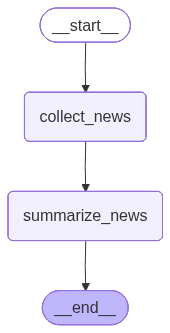

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Run the Graph

In [16]:
def run_news_graph(query: str | None = None) -> NewsGraphState:
    default_query = (
        "latest IT industry developments AI advancements AI agents frameworks "
        "tech market news past 48 hours"
    )

    workflow = build_graph()

    initial_state: NewsGraphState = {
        "query": query or default_query,
        "search_results": "",
        "curated_news": "",
        "final_digest": "",
    }

    return workflow.invoke(initial_state)

In [19]:

query = "latest IT industry developments AI advancements AI agents frameworks tech market news past 48 hours"
response = run_news_graph(query)
print("===== Final Digest =====")
for key, value in response.items():
    print(f"--- {key} ---\n{value}\n\n")
print(response["final_digest"], "\n\n")

[collect_news] searching web...
[collect_news] search complete (12015 chars), calling model...
[collect_news] model complete (5078 chars)
[summarize_news] generating final digest...
[summarize_news] complete
===== Final Digest =====
--- query ---
latest IT industry developments AI advancements AI agents frameworks tech market news past 48 hours


--- search_results ---
Title: Saltware Wins Government-Led AI Transformation Project for Semiconductor Industry - thelec.net
URL: https://www.thelec.net/news/articleView.html?idxno=10391
Snippet: * UPDATE : 2026-05-13 08:28 (Wed). Saltware Wins Government-Led AI Transformation Project for Semiconductor Industry. ## Project to deploy 21 AI agents across semiconductor manufacturing processes with contract value expected to exceed 3 billion won. * Published 2026.05.13 09:48. Saltware said Tuesday it has won an artificial intelligence agent deployment project backed by South Korea's National IT Industry Promotion Agency (NIPA). Saltware was select